# Parameter Search (Long Only)

This notebook performs an exhaustive search over all intraday entry/exit hour combinations on the in-sample EUR/USD dataset.

The objective is to identify time windows exhibiting persistent positive expectancy and strong risk-adjusted performance.

In [1]:
import pandas as pd

import sys
import os

sys.path.append(os.path.dirname(os.getcwd()))

from src.backtest import run_backtest, compute_metrics, generate_position, backtest_strategies
from src.plotting import format_results_table, plot_heatmap

In [2]:
# Load EURUSD H1 dataset
df_full = pd.read_csv("../data/eurusd_h1.csv")

# Convert timestamp column to datetime format
df_full["time"] = pd.to_datetime(df_full["time"])

# Set datetime as index for time-series operations
df_full = df_full.set_index("time")

In [5]:
# Reserve the most recent year as out-of-sample data.
# The remaining observations are used for research and strategy development.

split_date = "2024-01-01"

df = df_full[df_full.index < split_date].copy()

In [6]:
# Rename price column to a standard name used in the backtest engine
df = df.rename(columns={"close": "price"})

# Keep only relevant column for strategy/backtest
df = df[["price"]]

# Extract hour of day from datetime index to construct entry/exit trading signals
df["hour"] = df.index.hour

In [7]:
# Quick sanity check of the dataset structure

display(df)

df.info()

,price,hour
time,,
2018-04-06 08:00:00,1.22374,8
2018-04-06 09:00:00,1.22357,9
2018-04-06 10:00:00,1.22270,10
2018-04-06 11:00:00,1.22350,11
2018-04-06 12:00:00,1.22430,12
...,...,...
2023-12-29 19:00:00,1.10640,19
2023-12-29 20:00:00,1.10531,20
2023-12-29 21:00:00,1.10407,21


<class 'pandas.DataFrame'>
DatetimeIndex: 35654 entries, 2018-04-06 08:00:00 to 2023-12-29 23:00:00
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   35654 non-null  float64
 1   hour    35654 non-null  int32  
dtypes: float64(1), int32(1)
memory usage: 696.4 KB


## Exhaustive Intraday Search

Each strategy is defined by:
- an entry hour
- an exit hour

All possible combinations are backtested using the vectorized framework implemented in `src/backtest.py`.

Performance metrics are computed for every configuration and ranked by Sharpe ratio.

In [8]:
hours = range(24)

strategies = [
    {"entry_hour": entry_hour, "exit_hour": exit_hour}
    for entry_hour in hours
    for exit_hour in hours
    if entry_hour != exit_hour
]

# Run the backtest on all selected strategies
results_df, equity_curves = backtest_strategies(df, strategies)

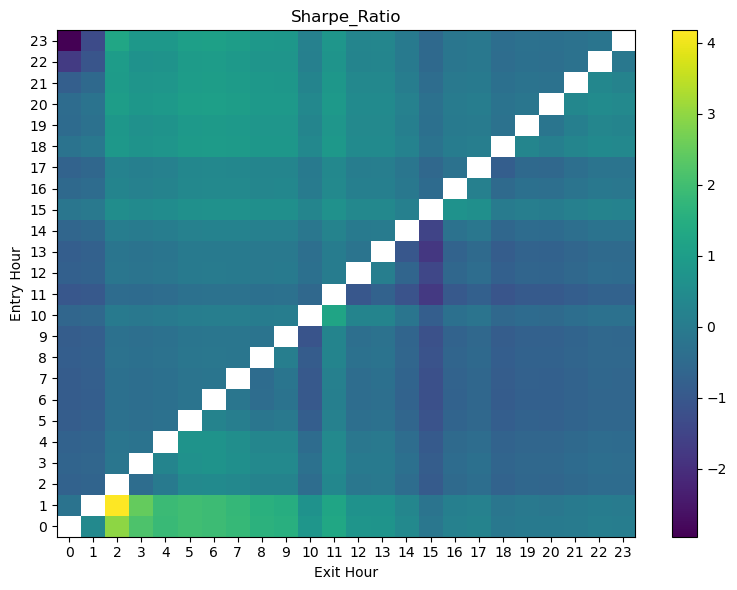

In [9]:
plot_heatmap(results_df, metric="Sharpe_Ratio")

## Strategy Ranking

The top-performing configurations are selected according to risk-adjusted returns.

The goal is not to maximize raw profitability, but to identify stable intraday structures with favorable return-to-risk characteristics.

In [10]:
# Sort by Sharpe Ratio
top_strategies = results_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
).head(15)

# Select relevant columns
top_strategies = top_strategies[
    [
        "entry_hour",
        "exit_hour",
        "CAGR",
        "Calmar_Ratio",
        "Sharpe_Ratio",
        "Max_Drawdown"
    ]
]

# Apply formatting
format_results_table(top_strategies)

,entry_hour,exit_hour,CAGR,Calmar_Ratio,Sharpe_Ratio,Max_Drawdown
strategy,,,,,,
1-2,1,2,3.49%,6.64,4.17,-0.52%
0-2,0,2,3.90%,2.25,2.97,-1.73%
1-3,1,3,3.11%,1.92,2.48,-1.61%
0-3,0,3,3.52%,1.18,2.19,-2.99%
1-5,1,5,4.25%,1.98,2.00,-2.15%
0-5,0,5,4.67%,1.12,1.98,-4.16%
0-6,0,6,4.89%,0.97,1.93,-5.03%
1-6,1,6,4.47%,1.62,1.93,-2.75%
1-4,1,4,3.43%,1.37,1.91,-2.51%


In [11]:
# Select the top 4 strategies from the top15 dataframe
top4 = top_strategies.head(4)

# Save the result to a CSV file
top4.to_csv("../data/top4_strategies.csv", index=False)

## Research Notes

The parameter search is conducted exclusively on the in-sample dataset and therefore should not be interpreted as evidence of predictive power.

The next stage of the research process consists of validating the selected configurations on unseen out-of-sample data.